## 2-3_Scaling_data_to_the_standard_normal

In [1]:
## 1. The preprocessing module contains several functions useful for feature scaling.

from sklearn import preprocessing
import pandas as pd
import numpy as np 
# we'll need it later
#Load the Boston dataset.

In [2]:
## 2. Let's load the California Housing dataset used in this recipe and set the explanatory and target variables.


from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing()

X, y = housing.data, housing.target

print(X.shape)
print(y.shape)

# Original cookbook code used load_boston().
# load_boston() was removed from scikit-learn 1.2,
# so California Housing is used instead.

(20640, 8)
(20640,)


In [3]:
## 3. Run the following commands using the California Housing dataset.

X[:, :3].mean(axis=0) 
# mean of the first 3 features

array([ 3.870671  , 28.63948643,  5.42899974])

In [4]:
X[:, :3].std(axis=0)
# std of the first 3 features

array([ 1.89977569, 12.58525273,  2.4741132 ])

In [5]:
## 4. Perform centering and scaling on the three features

X_2 = preprocessing.scale(X[:, :3])
X_2.mean(axis=0)

array([5.50808322e-17, 4.40646658e-17, 7.71131651e-17])

In [6]:
X_2.std(axis=0)

array([1., 1., 1.])

<Axes: >

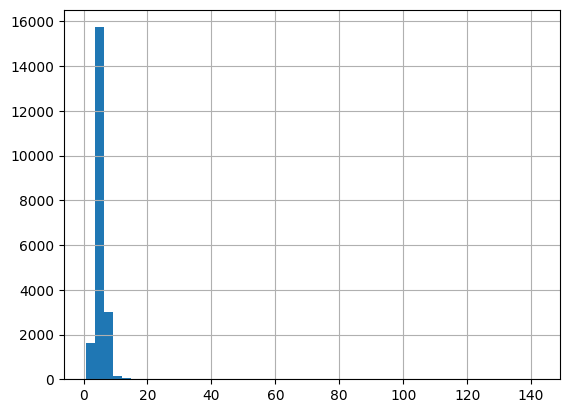

In [7]:
## 5. Before performing the transformation using the `scale` function, visualizing the third feature using pandas yields the following result.

%matplotlib inline
pd.Series(X[:,2]).hist(bins=50)

<Axes: >

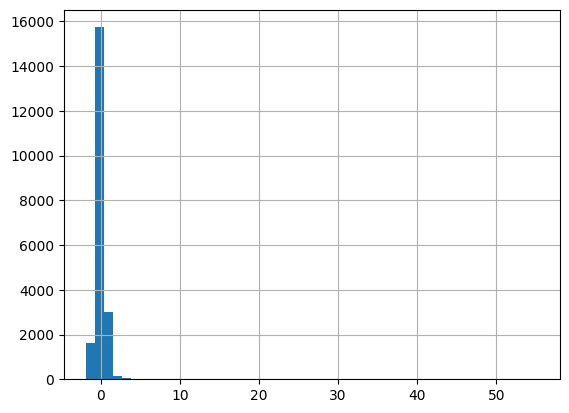

In [8]:
## 6. After conversion using the scale function, the result is as follows.

pd.Series(preprocessing.scale(X[:, 2])).hist(bins=50)
## The X-axis labels are changing.

In [9]:
## 5. There are also classes that perform centering and scaling.

my_scaler = preprocessing.StandardScaler()
my_scaler.fit(X[:, :3])
my_scaler.transform(X[:, :3]).mean(axis=0)

array([5.50808322e-17, 4.40646658e-17, 7.71131651e-17])

In [10]:
## 6. Scaling features to have a mean of 0 and a standard deviation of 1 is not the only form of useful scaling.
## The preprocessing module also includes the MinMaxScaler class. This class scales data to a specific range.

my_minmax_scaler = preprocessing.MinMaxScaler()
my_minmax_scaler.fit(X[:, :3])
my_minmax_scaler.transform(X[:, :3]).max(axis=0)


array([1., 1., 1.])

In [11]:
my_minmax_scaler.transform(X[:, :3]).min(axis=0)

array([0., 0., 0.])

In [12]:
## 7. Specify the minimum and maximum values ​​as arguments for the `feature_range` parameter, as shown below.

my_odd_scaler = preprocessing.MinMaxScaler(feature_range=(-3.14, 3.14))


In [13]:
## 8. Furthermore, there is the option of normalization. Each sample is scaled to have a length of 1.

normalized_X = preprocessing.normalize(X[:, :3]) 

In [14]:
## 9. All rows are normalized and consist of vectors with a length of 1.

(normalized_X * normalized_X).sum(axis = 1)

array([1., 1., 1., ..., 1., 1., 1.], shape=(20640,))